# Credit Card Fraud Detection Analysis


This project analyses real-world credit card transaction data to identify
fraudulent patterns. It demonstrates data cleaning, exploratory analysis,
and fraud detection techniques relevant to financial services.

**Dataset**: [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Tools:** Python, Pandas, Matplotlib, Google Colab

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('creditcard.csv')


print("Dataset shape:", df.shape)
print('Duplicate Rows   :', df.duplicated().sum())
print('Missing Values   :', df.isnull().sum().sum())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (184307, 31)
Duplicate Rows   : 671
Missing Values   : 26

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
df.drop_duplicates(inplace=True)
print(f'Shape after removing duplicates: {df.shape}')



Shape after removing duplicates: (183636, 31)


##  Zero Amount Analysis
Investigating zero value transactions.

**Key Finding:** 1 252 zero-amount transactions were found, of which 15 are
fraudulent. These are consistent with **card probing** , a technique where
fraudsters test stolen cards with R0.00 before making larger purchases.
Zero-amount transactions were retained and flagged rather than removed.

In [ ]:

zero_amounts = df[df['Amount'] == 0]
print(f"Zero amount transactions: {len(zero_amounts)}")


zero_fraud = df[(df['Amount'] == 0) & (df['Class'] == 1)]
print(f"Zero amount fraudulent transactions: {len(zero_fraud)}")

fraud_probe_rate = (len(zero_fraud) / len(zero_amounts)) * 100
print(f"Fraud rate in zero transactions:     {fraud_probe_rate:.2f}%")


overall_fraud_rate = (len(df[df['Class'] == 1]) / len(df)) * 100
print(f"Overall dataset fraud rate:          {overall_fraud_rate:.2f}%")




Zero amount transactions: 1252
Zero amount fraudulent transactions: 15
Fraud rate in zero transactions:     1.20%
Overall dataset fraud rate:          0.19%


## Low-Value Fraud Analysis
Analysing whether fraudsters prefer smaller transaction amounts to avoid
detection.

**Key Finding:** over 98% of fraud occurs in transactions under 1000, consistent
with smurfing, where fraudsters deliberately keep amounts small to stay
under bank alert thresholds.

Transaction Amount Statistics:
count    183635.000000
mean         88.769243
std         247.708372
min           0.000000
25%           5.840000
50%          22.610000
75%          78.650000
max       19656.530000
Name: Amount, dtype: float64
Total Fraudulent Transactions: 349

Transactions over 1000: 1913
Transactions under 1000: 181650
Fraudulent transactions over 1000: 6
Fraudulent transactions under 1000: 343


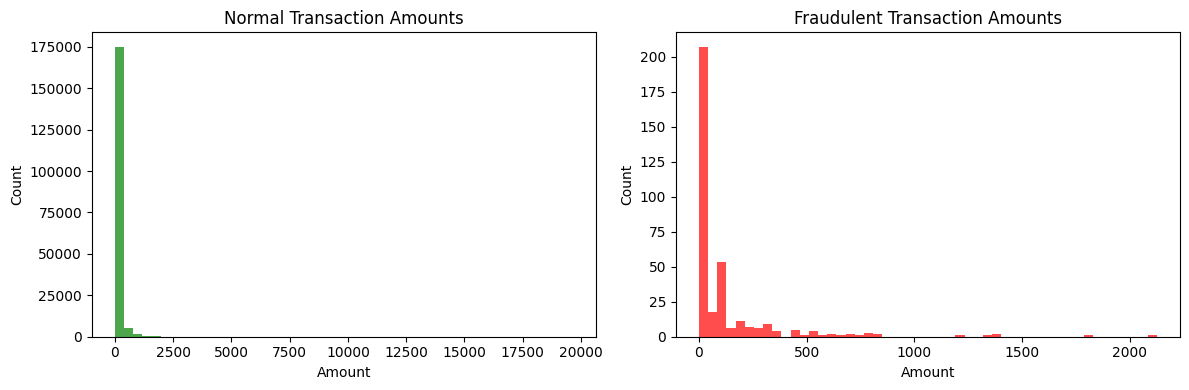

In [34]:
# Look at the distribution of transaction amounts
print("Transaction Amount Statistics:")
print(df['Amount'].describe())
total_fraud = len(df[df['Class'] == 1])
print(f"Total Fraudulent Transactions: {total_fraud}")
# Flag extreme outliers (amounts over 1000)
extreme = df[df['Amount'] > 1000]
LowAmounts =df[df['Amount'] < 1000]
extreme_fraud = df[(df['Amount'] > 1000) & (df['Class'] == 1)]
LowAmounts_fraud = df[(df['Amount'] < 1000) & (df['Class'] == 1)]

print(f"\nTransactions over 1000: {len(extreme)}")
print(f"Transactions under 1000: {len(LowAmounts)}")
print(f"Fraudulent transactions over 1000: {len(extreme_fraud)}")
print(f"Fraudulent transactions under 1000: {len(LowAmounts_fraud)}")


# Visualise amount distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df[df['Class'] == 0]['Amount'], bins=50, color='green', alpha=0.7)
plt.title('Normal Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(df[df['Class'] == 1]['Amount'], bins=50, color='red', alpha=0.7)
plt.title('Fraudulent Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

0 = Normal Transaction, 1 = Fraudulent Transaction
Class
0.0    49461
1.0      148
Name: count, dtype: int64


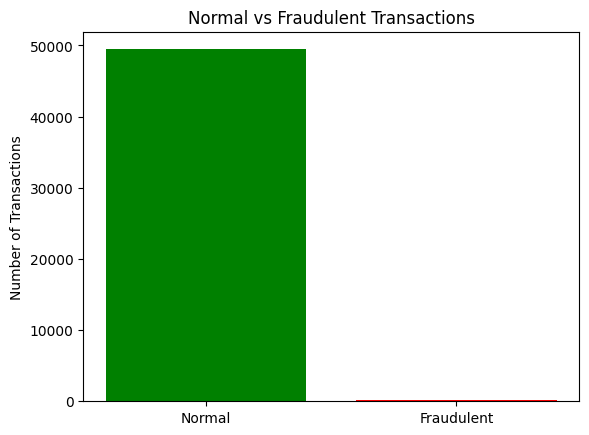

In [ ]:
fraud_counts = df['Class'].value_counts()
print("0 = Normal Transaction, 1 = Fraudulent Transaction")
print(fraud_counts)


labels = ['Normal', 'Fraudulent']
values = [fraud_counts[0], fraud_counts[1]]

plt.bar(labels, values, color=['green', 'red'])
plt.title('Normal vs Fraudulent Transactions')
plt.ylabel('Number of Transactions')
plt.show()

In [37]:

total = len(df)
total_fraud = len(df[df['Class'] == 1])
total_normal = len(df[df['Class'] == 0])
fraud_percentage = (total_fraud / total) * 100

print("=" * 30)
print("FRAUD DETECTION SUMMARY")
print("=" * 30)
print(f"Total Transactions: {total:,}")
print(f"Normal Transactions: {total_normal:,}")
print(f"Fraudulent Transactions: {total_fraud:,}")
print(f"Fraud Rate: {fraud_percentage:.2f}%")
print("=" * 30)

FRAUD DETECTION SUMMARY
Total Transactions: 183,636
Normal Transactions: 183,286
Fraudulent Transactions: 349
Fraud Rate: 0.19%


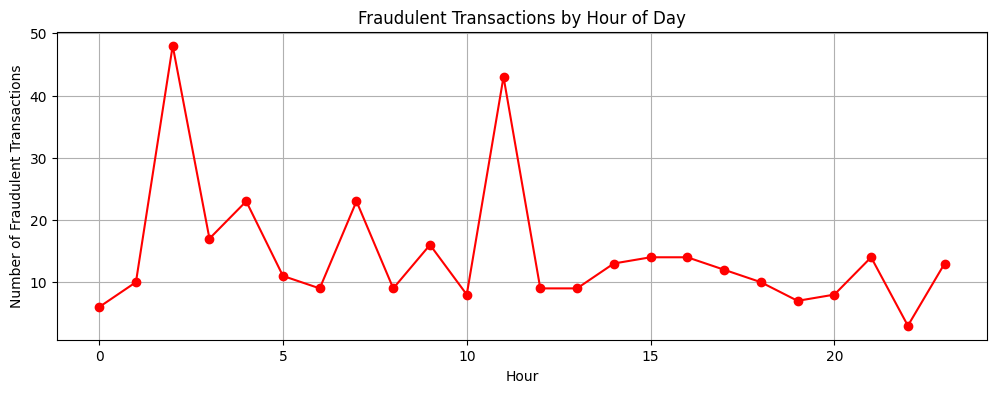

In [33]:

df['Hour'] = (df['Time'] // 3600) % 24

fraud_by_hour = df[df['Class'] == 1].groupby('Hour').size()

plt.figure(figsize=(12, 4))
plt.plot(fraud_by_hour.index, fraud_by_hour.values, color='red', marker='o')
plt.title('Fraudulent Transactions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Fraudulent Transactions')
plt.grid(True)
plt.show()